In [1]:
import pandas as pd
df = pd.read_csv("DATASET_RETAIL.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  1380 non-null   int64  
 1   Date            1380 non-null   str    
 2   Day             1380 non-null   str    
 3   Time            1380 non-null   str    
 4   Hour            1380 non-null   int64  
 5   Category        1380 non-null   str    
 6   Product         1380 non-null   str    
 7   Quantity        1380 non-null   int64  
 8   Unit_Price      1380 non-null   int64  
 9   Bill_Amount     1380 non-null   int64  
 10  Payment_Mode    1380 non-null   str    
 11  Customer_Type   1380 non-null   str    
 12  Discount        1380 non-null   int64  
 13  Final_Bill      1380 non-null   int64  
 14  Rating          1380 non-null   float64
 15  Is_Weekend      1380 non-null   str    
dtypes: float64(1), int64(7), str(8)
memory usage: 172.6 KB


In [2]:
df['Date'] = pd.to_datetime(df["Date"])
df['Time'] = pd.to_datetime(df["Time"], format = "%H:%M").dt.time

In [3]:
miss_values = df.isnull().sum()
print(f"Missing values:\n{miss_values}")

Missing values:
Transaction_ID    0
Date              0
Day               0
Time              0
Hour              0
Category          0
Product           0
Quantity          0
Unit_Price        0
Bill_Amount       0
Payment_Mode      0
Customer_Type     0
Discount          0
Final_Bill        0
Rating            0
Is_Weekend        0
dtype: int64


In [4]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows:\n{duplicates}")

Duplicate rows:
0


In [5]:

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Day']= pd.Categorical(df["Day"], categories = days, ordered = True)

In [6]:
df['Unit_Price'] = df['Unit_Price'].astype(float)
df['Bill_Amount'] = df['Bill_Amount'].astype(float)
df['Discount'] = df['Discount'].astype(float)
df['Final_Bill'] = df['Final_Bill'].astype(float)
print(df.dtypes)

Transaction_ID             int64
Date              datetime64[us]
Day                     category
Time                      object
Hour                       int64
Category                     str
Product                      str
Quantity                   int64
Unit_Price               float64
Bill_Amount              float64
Payment_Mode                 str
Customer_Type                str
Discount                 float64
Final_Bill               float64
Rating                   float64
Is_Weekend                   str
dtype: object


In [7]:
sales_by_day = df.groupby('Day')['Bill_Amount'].sum()
print(f"Sales by day:\n{sales_by_day}")

Sales by day:
Day
Monday       30375.0
Tuesday      43195.0
Wednesday    47450.0
Thursday     50025.0
Friday       59680.0
Saturday     37220.0
Sunday       73330.0
Name: Bill_Amount, dtype: float64


In [8]:
highest_sales_day = sales_by_day.idxmax()
highest_sales_amount = sales_by_day.max()
print(f"Highest sales day: {highest_sales_day} \namount: {highest_sales_amount}")

Highest sales day: Sunday 
amount: 73330.0


In [9]:
lowest_sales_day = sales_by_day.idxmin()
lowest_sales_amount = sales_by_day.min()
print(f"Lowest sales day: {lowest_sales_day} \namount: {lowest_sales_amount}")

Lowest sales day: Monday 
amount: 30375.0


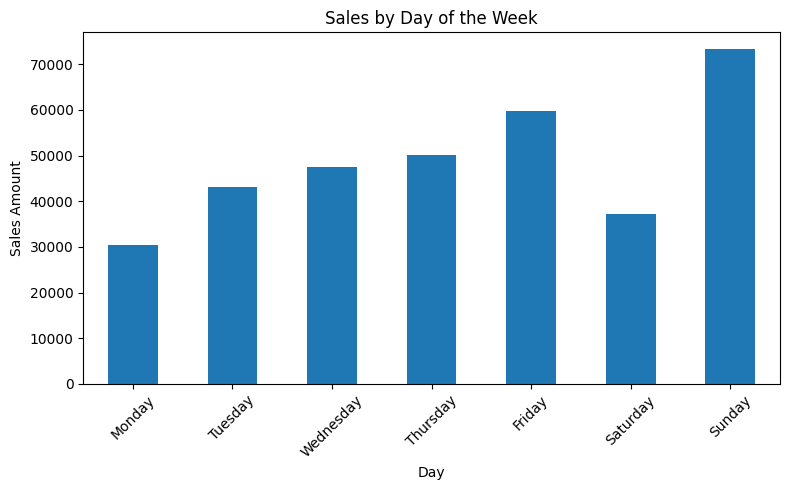

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sales_by_day.plot(kind='bar')
plt.title('Sales by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
slot = ['Morning', 'Late Morning', 'Afternoon', 'Evening', 'Night']
def get_time_slot(hour):
    if 6<= hour < 10:
        return slot[0]
    elif 10 <= hour < 14:
        return slot[1]
    elif 14 <= hour < 17:
        return slot[2]
    elif 17 <= hour < 21:
        return slot[3]
    else:
        return slot[4]

df['Time_Slot'] = df['Hour'].apply(get_time_slot)
df['Time_Slot']= pd.Categorical(df["Time_Slot"], categories = slot, ordered = True)

In [12]:
sales_by_time = df.groupby('Time_Slot')['Bill_Amount'].sum()
print(sales_by_time)
peak_time = sales_by_time.idxmax()
print("Peak Shopping Duration:", peak_time)

Time_Slot
Morning          21770.0
Late Morning     65475.0
Afternoon       155450.0
Evening          88920.0
Night             9660.0
Name: Bill_Amount, dtype: float64
Peak Shopping Duration: Afternoon


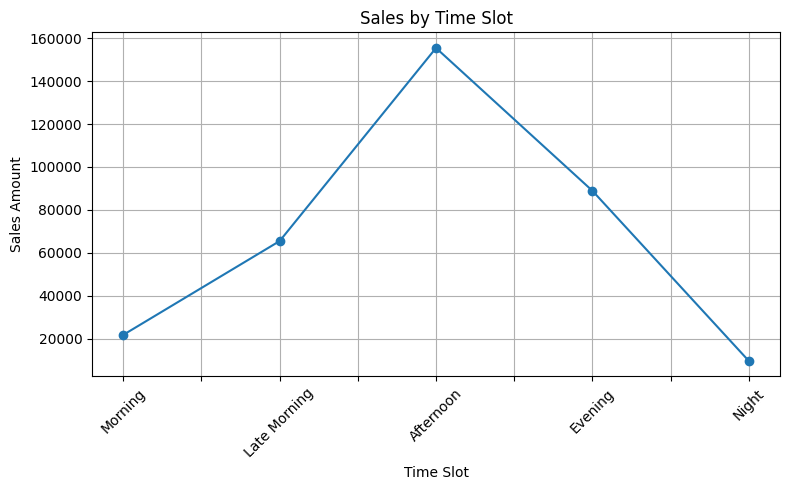

In [13]:
plt.figure(figsize=(8,5))
sales_by_time.plot(kind='line', marker='o')
plt.title('Sales by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()